In [1]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [2]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 32
    epochs = 15
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8

config = Config()

In [3]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        self.enc1 = self.conv_block(in_channels, 64)
        self.enc2 = self.conv_block(64, 128)
        self.enc3 = self.conv_block(128, 256)
        self.enc4 = self.conv_block(256, 512)

        self.bottleneck = self.conv_block(512, 1024)
        self.upconv4 = self.upconv_block(1024, 512)
        self.dec4 = self.conv_block(1024, 512)
        self.upconv3 = self.upconv_block(512, 256)
        self.dec3 = self.conv_block(512, 256)
        self.upconv2 = self.upconv_block(256, 128)
        self.dec2 = self.conv_block(256, 128)
        self.upconv1 = self.upconv_block(128, 64)
        self.dec1 = self.conv_block(128, 64)
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def upconv_block(self, in_channels, out_channels):
      return nn.Sequential(
          nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2),
          nn.BatchNorm2d(out_channels),
          nn.ReLU(inplace=True)
      )

    def forward(self, x):
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool(enc1))
        enc3 = self.enc3(self.pool(enc2))
        enc4 = self.enc4(self.pool(enc3))

        bottleneck = self.bottleneck(self.pool(enc4))

        up4 = self.upconv4(bottleneck)
        if up4.shape != enc4.shape:
            up4 = F.interpolate(up4, size=enc4.shape[2:], mode='bilinear', align_corners=False)
        concat4 = torch.cat([up4, enc4], dim=1)
        dec4 = self.dec4(concat4)

        up3 = self.upconv3(dec4)
        if up3.shape != enc3.shape:
            up3 = F.interpolate(up3, size=enc3.shape[2:], mode='bilinear', align_corners=False)
        concat3 = torch.cat([up3, enc3], dim=1)
        dec3 = self.dec3(concat3)

        up2 = self.upconv2(dec3)
        if up2.shape != enc2.shape:
            up2 = F.interpolate(up2, size=enc2.shape[2:], mode='bilinear', align_corners=False)
        concat2 = torch.cat([up2, enc2], dim=1)
        dec2 = self.dec2(concat2)

        up1 = self.upconv1(dec2)
        if up1.shape != enc1.shape:
            up1 = F.interpolate(up1, size=enc1.shape[2:], mode='bilinear', align_corners=False)
        concat1 = torch.cat([up1, enc1], dim=1)
        dec1 = self.dec1(concat1)

        output = self.final_conv(dec1)
        return output

In [9]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [4]:
class Trainer:
    def __init__(self, config):
        self.config = config

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

        self.model = UNet().to(config.device)
        self.criterion = nn.BCEWithLogitsLoss() # какой лосс удобный возьмем для бинарной сегментации?
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.setup_dataloader()

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)

    def run(self):
        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()

        print(f"Test Loss: {test_loss:.4f}, "
              f"Test IoU: {test_iou:.4f}, "
              f"Test F1-score: {test_f1:.4f}")

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                axes[i, 0].imshow(img.permute(1, 2, 0).cpu())
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

            plt.show()


In [ ]:
trainer = Trainer(config)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [5]:
import itertools
import copy


Обучение с параметрами: learning_rate=0.0001, batch_size=16
----------------------------------------


100%|██████████| 46/46 [00:12<00:00,  3.58it/s]


Epoch 1 / 15, Train Loss: 0.4027, Val Loss: 0.3115, Val IoU: 0.8265, Val F1-score: 0.8998


100%|██████████| 46/46 [00:12<00:00,  3.54it/s]


Epoch 2 / 15, Train Loss: 0.2922, Val Loss: 0.2729, Val IoU: 0.8473, Val F1-score: 0.9115


...

Epoch 14 / 15, Train Loss: 0.0981, Val Loss: 0.1907, Val IoU: 0.8941, Val F1-score: 0.9408


100%|██████████| 46/46 [00:12<00:00,  3.68it/s]


Epoch 15 / 15, Train Loss: 0.0980, Val Loss: 0.1913, Val IoU: 0.8934, Val F1-score: 0.9405
Testing...


100%|██████████| 230/230 [01:04<00:00,  3.56it/s]


Test Loss: 0.1940, Test IoU: 0.8933, Test F1-score: 0.9399

Результаты для learning_rate=0.0001, batch_size=16:


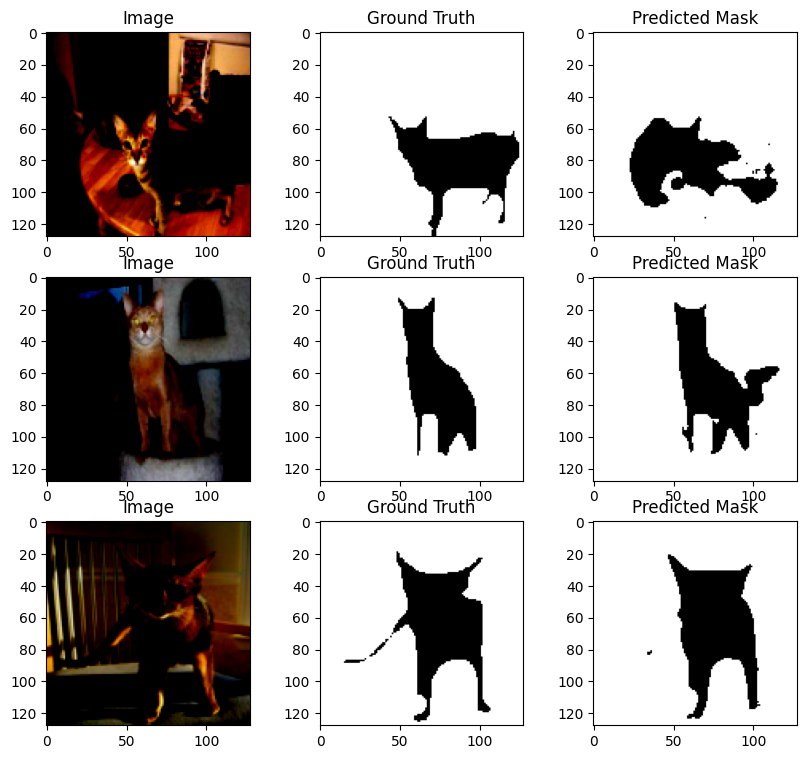


Обучение с параметрами: learning_rate=0.0001, batch_size=32
----------------------------------------


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 23/23 [00:12<00:00,  1.91it/s]


Epoch 1 / 15, Train Loss: 0.4897, Val Loss: 0.4654, Val IoU: 0.7468, Val F1-score: 0.8485


100%|██████████| 23/23 [00:12<00:00,  1.90it/s]


Epoch 2 / 15, Train Loss: 0.3583, Val Loss: 0.3318, Val IoU: 0.8353, Val F1-score: 0.9055


...

Epoch 14 / 15, Train Loss: 0.1166, Val Loss: 0.2063, Val IoU: 0.8869, Val F1-score: 0.9368


100%|██████████| 23/23 [00:12<00:00,  1.88it/s]


Epoch 15 / 15, Train Loss: 0.1010, Val Loss: 0.2045, Val IoU: 0.8913, Val F1-score: 0.9394
Testing...


100%|██████████| 115/115 [01:01<00:00,  1.86it/s]


Test Loss: 0.2026, Test IoU: 0.8903, Test F1-score: 0.9375

Результаты для learning_rate=0.0001, batch_size=32:


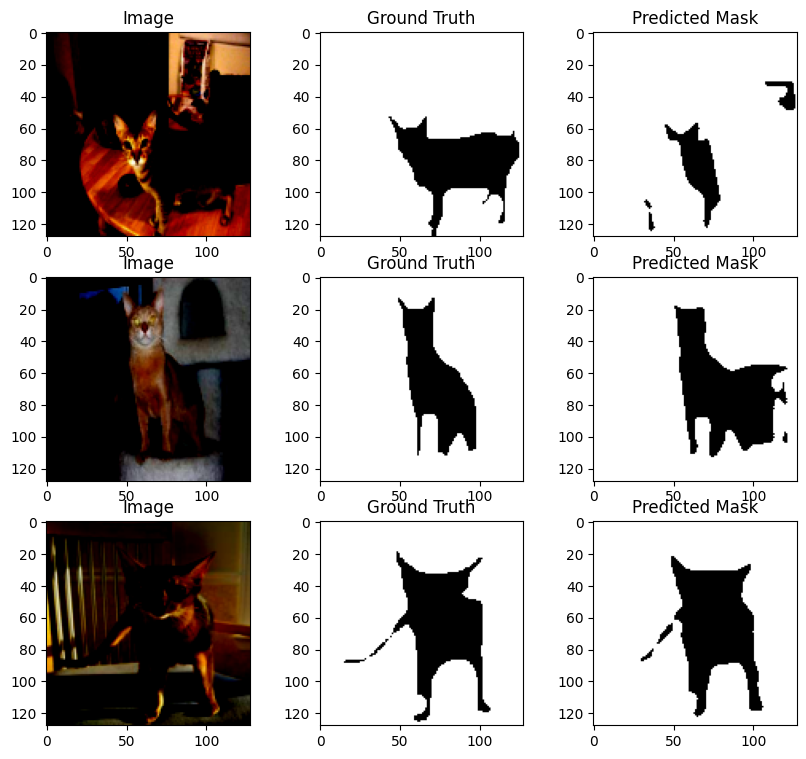


Обучение с параметрами: learning_rate=0.0001, batch_size=64
----------------------------------------


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 12/12 [00:12<00:00,  1.04s/it]


Epoch 1 / 15, Train Loss: 0.4904, Val Loss: 0.3926, Val IoU: 0.7967, Val F1-score: 0.8803


100%|██████████| 12/12 [00:12<00:00,  1.04s/it]


Epoch 2 / 15, Train Loss: 0.3617, Val Loss: 0.3536, Val IoU: 0.8248, Val F1-score: 0.8977


...

Epoch 14 / 15, Train Loss: 0.1263, Val Loss: 0.2523, Val IoU: 0.8657, Val F1-score: 0.9236


100%|██████████| 12/12 [00:12<00:00,  1.03s/it]


Epoch 15 / 15, Train Loss: 0.1211, Val Loss: 0.2493, Val IoU: 0.8688, Val F1-score: 0.9251
Testing...


100%|██████████| 58/58 [01:03<00:00,  1.09s/it]


Test Loss: 0.2433, Test IoU: 0.8699, Test F1-score: 0.9253

Результаты для learning_rate=0.0001, batch_size=64:


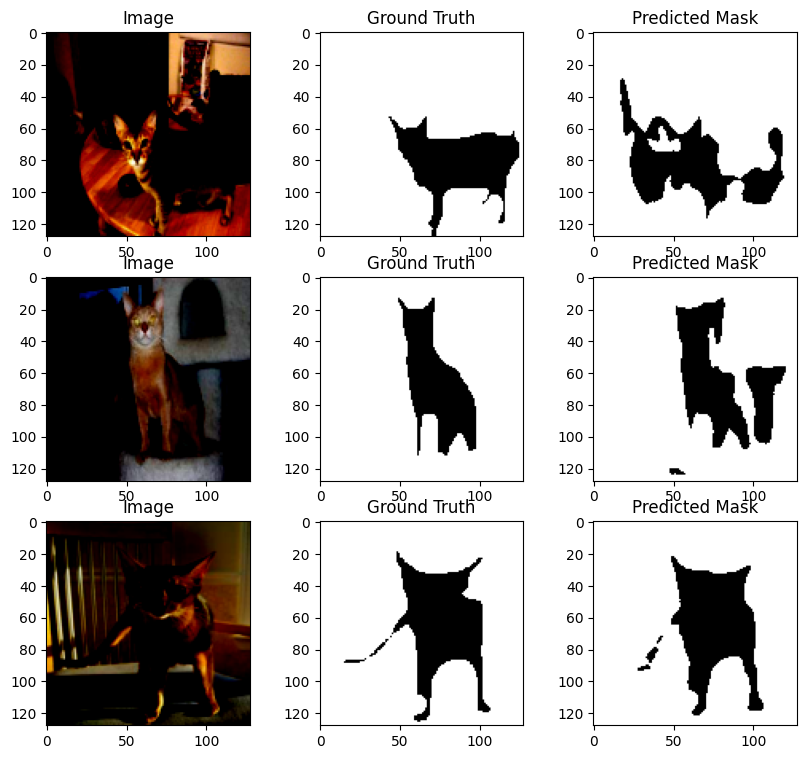


Обучение с параметрами: learning_rate=0.001, batch_size=16
----------------------------------------


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 46/46 [00:12<00:00,  3.54it/s]


Epoch 1 / 15, Train Loss: 0.4507, Val Loss: 0.3785, Val IoU: 0.7784, Val F1-score: 0.8697


100%|██████████| 46/46 [00:12<00:00,  3.59it/s]


Epoch 2 / 15, Train Loss: 0.3724, Val Loss: 0.4213, Val IoU: 0.7826, Val F1-score: 0.8694


...

Epoch 14 / 15, Train Loss: 0.1660, Val Loss: 0.1872, Val IoU: 0.8901, Val F1-score: 0.9390


100%|██████████| 46/46 [00:12<00:00,  3.59it/s]


Epoch 15 / 15, Train Loss: 0.1569, Val Loss: 0.1851, Val IoU: 0.8924, Val F1-score: 0.9400
Testing...


100%|██████████| 230/230 [01:04<00:00,  3.54it/s]


Test Loss: 0.1868, Test IoU: 0.8888, Test F1-score: 0.9368

Результаты для learning_rate=0.001, batch_size=16:


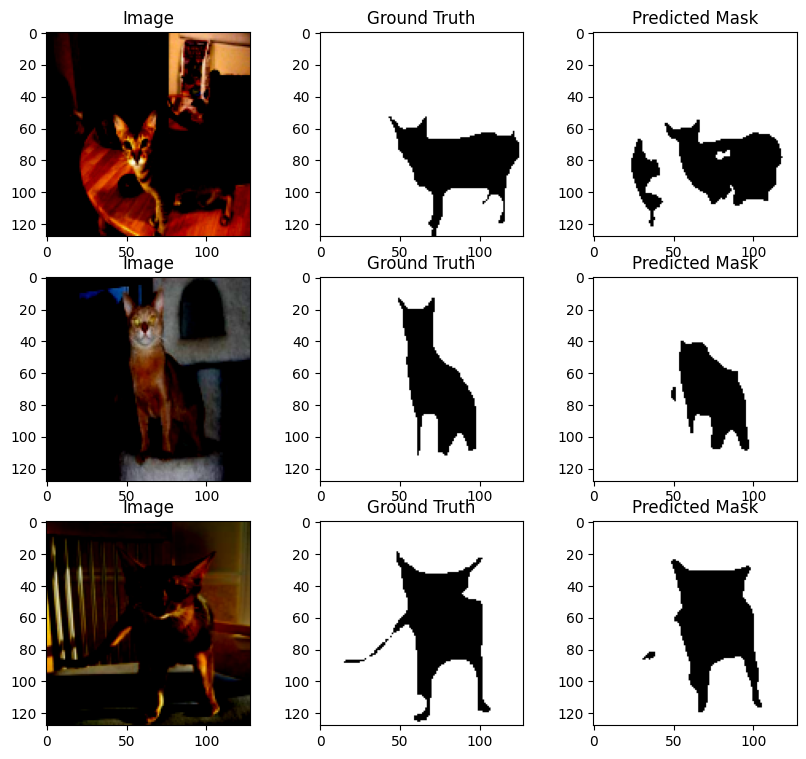


Обучение с параметрами: learning_rate=0.001, batch_size=32
----------------------------------------


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 23/23 [00:12<00:00,  1.90it/s]


Epoch 1 / 15, Train Loss: 0.4795, Val Loss: 0.5065, Val IoU: 0.7501, Val F1-score: 0.8521


100%|██████████| 23/23 [00:11<00:00,  1.94it/s]


Epoch 2 / 15, Train Loss: 0.3870, Val Loss: 0.3801, Val IoU: 0.7683, Val F1-score: 0.8632


...

Epoch 14 / 15, Train Loss: 0.1653, Val Loss: 0.1854, Val IoU: 0.8949, Val F1-score: 0.9421


100%|██████████| 23/23 [00:11<00:00,  1.92it/s]


Epoch 15 / 15, Train Loss: 0.1564, Val Loss: 0.1923, Val IoU: 0.8898, Val F1-score: 0.9387
Testing...


100%|██████████| 115/115 [01:00<00:00,  1.90it/s]


Test Loss: 0.1980, Test IoU: 0.8856, Test F1-score: 0.9352

Результаты для learning_rate=0.001, batch_size=32:


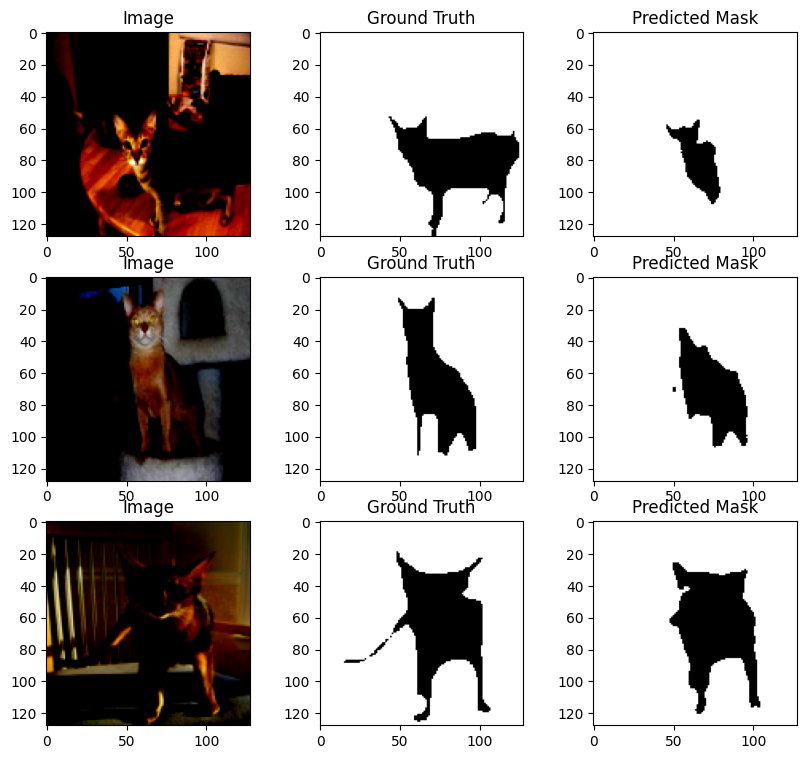


Обучение с параметрами: learning_rate=0.001, batch_size=64
----------------------------------------


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 12/12 [00:12<00:00,  1.03s/it]


Epoch 1 / 15, Train Loss: 0.4672, Val Loss: 0.4179, Val IoU: 0.7574, Val F1-score: 0.8558


100%|██████████| 12/12 [00:12<00:00,  1.03s/it]


Epoch 2 / 15, Train Loss: 0.3644, Val Loss: 0.4549, Val IoU: 0.7349, Val F1-score: 0.8361


...

Epoch 14 / 15, Train Loss: 0.1456, Val Loss: 0.1999, Val IoU: 0.8881, Val F1-score: 0.9371


100%|██████████| 12/12 [00:12<00:00,  1.02s/it]


Epoch 15 / 15, Train Loss: 0.1412, Val Loss: 0.2086, Val IoU: 0.8865, Val F1-score: 0.9362
Testing...


100%|██████████| 58/58 [01:02<00:00,  1.07s/it]


Test Loss: 0.2019, Test IoU: 0.8848, Test F1-score: 0.9343

Результаты для learning_rate=0.001, batch_size=64:


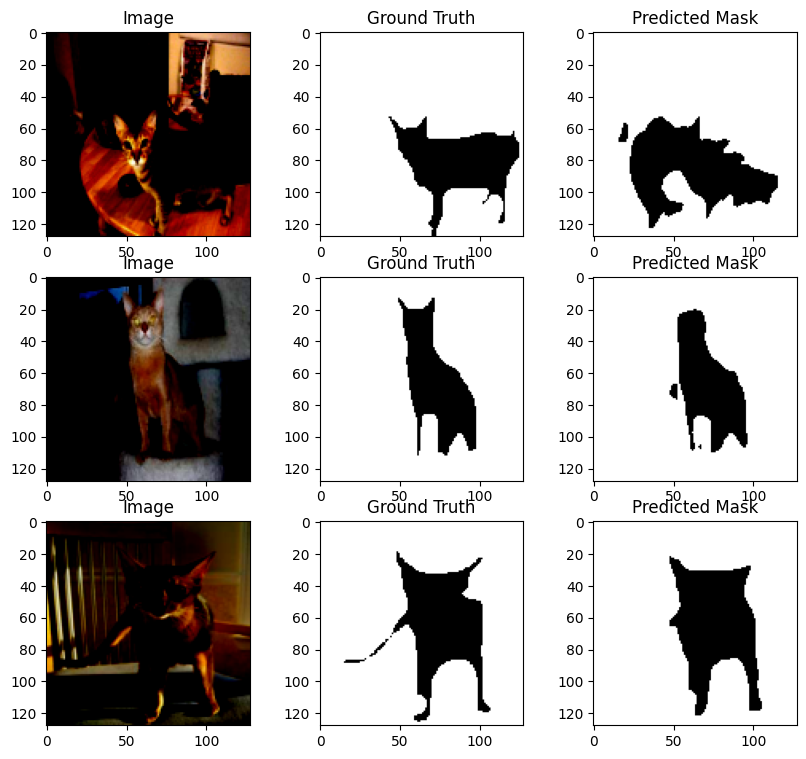


Обучение с параметрами: learning_rate=0.01, batch_size=16
----------------------------------------


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 46/46 [00:12<00:00,  3.66it/s]


Epoch 1 / 15, Train Loss: 0.4977, Val Loss: 0.4650, Val IoU: 0.7211, Val F1-score: 0.8328


100%|██████████| 46/46 [00:13<00:00,  3.53it/s]


Epoch 2 / 15, Train Loss: 0.4264, Val Loss: 0.4757, Val IoU: 0.7531, Val F1-score: 0.8509


...

Epoch 14 / 15, Train Loss: 0.2023, Val Loss: 0.2502, Val IoU: 0.8525, Val F1-score: 0.9158


100%|██████████| 46/46 [00:13<00:00,  3.51it/s]


Epoch 15 / 15, Train Loss: 0.1868, Val Loss: 0.2369, Val IoU: 0.8611, Val F1-score: 0.9208
Testing...


100%|██████████| 230/230 [01:06<00:00,  3.44it/s]


Test Loss: 0.2321, Test IoU: 0.8628, Test F1-score: 0.9208

Результаты для learning_rate=0.01, batch_size=16:


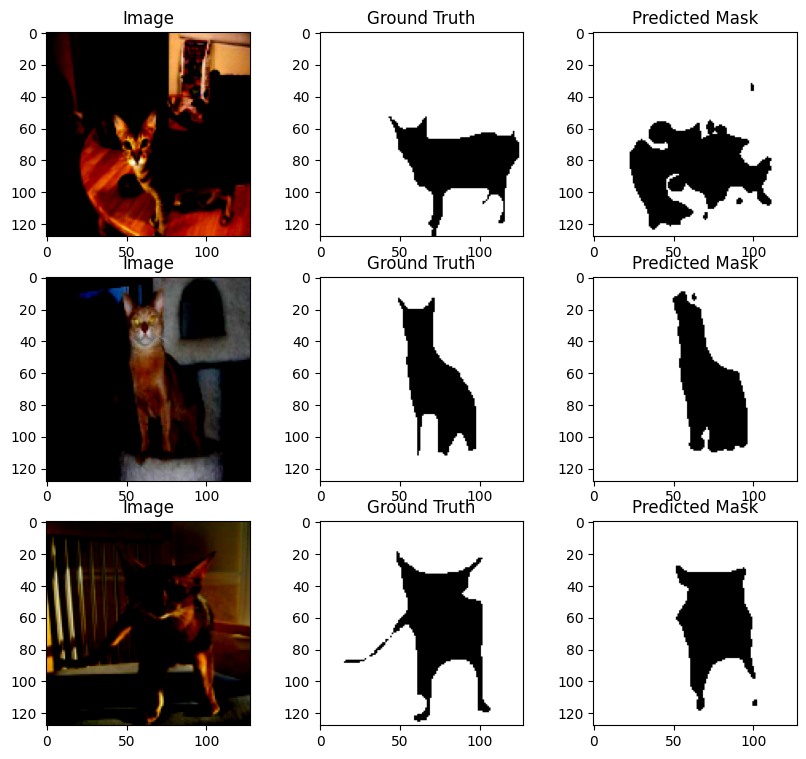


Обучение с параметрами: learning_rate=0.01, batch_size=32
----------------------------------------


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 23/23 [00:12<00:00,  1.91it/s]


Epoch 1 / 15, Train Loss: 0.5773, Val Loss: 0.5594, Val IoU: 0.7043, Val F1-score: 0.8155


100%|██████████| 23/23 [00:12<00:00,  1.88it/s]


Epoch 2 / 15, Train Loss: 0.5212, Val Loss: 0.5259, Val IoU: 0.6531, Val F1-score: 0.7840


...

Epoch 14 / 15, Train Loss: 0.2384, Val Loss: 0.2582, Val IoU: 0.8506, Val F1-score: 0.9145


100%|██████████| 23/23 [00:12<00:00,  1.90it/s]


Epoch 15 / 15, Train Loss: 0.2248, Val Loss: 0.2446, Val IoU: 0.8574, Val F1-score: 0.9188
Testing...


100%|██████████| 115/115 [01:01<00:00,  1.88it/s]


Test Loss: 0.2485, Test IoU: 0.8533, Test F1-score: 0.9154

Результаты для learning_rate=0.01, batch_size=32:


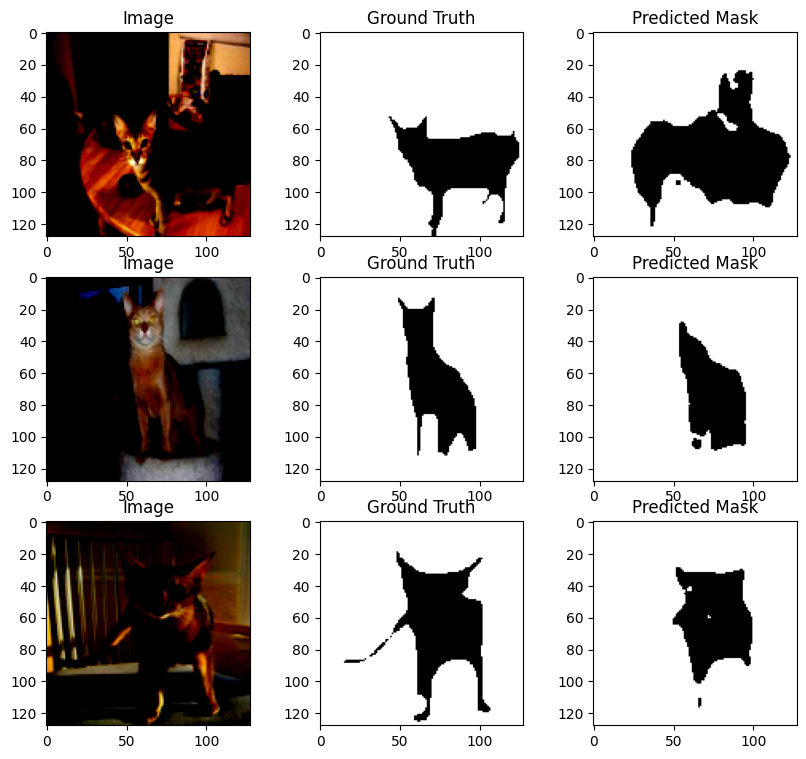


Обучение с параметрами: learning_rate=0.01, batch_size=64
----------------------------------------


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 12/12 [00:12<00:00,  1.03s/it]


Epoch 1 / 15, Train Loss: 0.5355, Val Loss: 0.4947, Val IoU: 0.7122, Val F1-score: 0.8269


100%|██████████| 12/12 [00:12<00:00,  1.05s/it]


Epoch 2 / 15, Train Loss: 0.4245, Val Loss: 0.4336, Val IoU: 0.7377, Val F1-score: 0.8428


...

Epoch 14 / 15, Train Loss: 0.2406, Val Loss: 0.2880, Val IoU: 0.8365, Val F1-score: 0.9053


100%|██████████| 12/12 [00:12<00:00,  1.04s/it]


Epoch 15 / 15, Train Loss: 0.2250, Val Loss: 0.3829, Val IoU: 0.8161, Val F1-score: 0.8915
Testing...


100%|██████████| 58/58 [01:04<00:00,  1.11s/it]


Test Loss: 0.3608, Test IoU: 0.8248, Test F1-score: 0.8963

Результаты для learning_rate=0.01, batch_size=64:


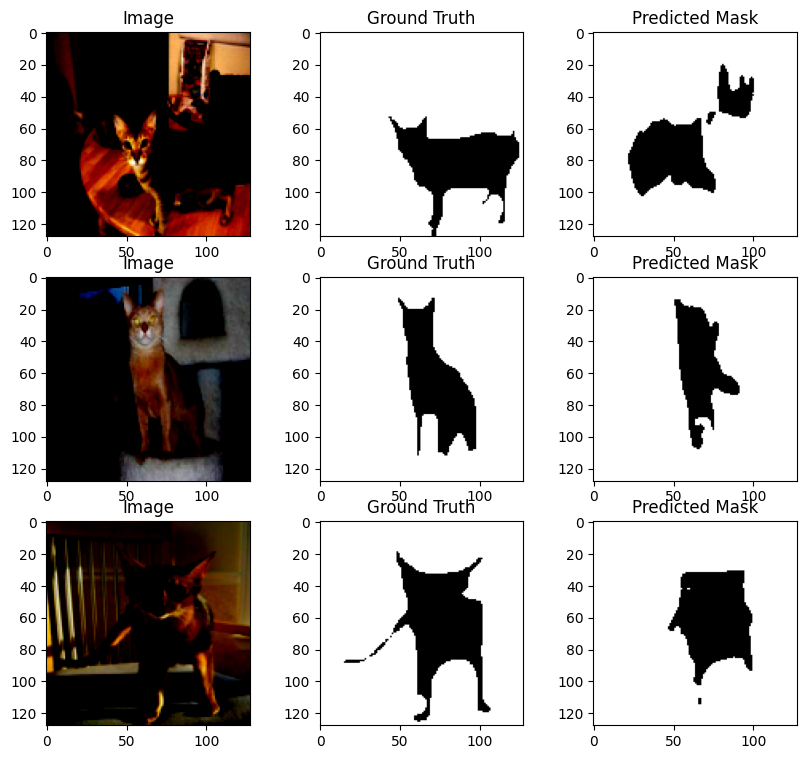

In [ ]:
learning_rates = [0.0001, 0.001, 0.01]
batch_sizes = [16, 32, 64]

param_combinations = list(itertools.product(learning_rates, batch_sizes))

results = {}

for lr, bs in param_combinations:
    print(f"\nОбучение с параметрами: learning_rate={lr}, batch_size={bs}")
    print("-" * 40)

    config_copy = copy.deepcopy(config)
    config_copy.learning_rate = lr
    config_copy.batch_size = bs

    trainer = Trainer(config_copy)
    trainer.run()

    results[(lr, bs)] = trainer

    print(f"\nРезультаты для learning_rate={lr}, batch_size={bs}:")
    trainer.inference_and_plot_samples(n_samples=3)

Лучший набор параметров — learning_rate=0.0001, batch_size=16, так как он обеспечивает самые высокие итоговые метрики на тестовой выборке (IoU 0.8933, F1 0.9399) при минимальном значении функции потерь (Test Loss 0.1940).

## Модификация: нормализация слоёв

In [6]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        self.enc1 = self.conv_block(in_channels, 64)
        self.enc2 = self.conv_block(64, 128)
        self.enc3 = self.conv_block(128, 256)
        self.enc4 = self.conv_block(256, 512)

        self.bottleneck = self.conv_block(512, 1024)
        self.upconv4 = self.upconv_block(1024, 512)
        self.dec4 = self.conv_block(1024, 512)
        self.upconv3 = self.upconv_block(512, 256)
        self.dec3 = self.conv_block(512, 256)
        self.upconv2 = self.upconv_block(256, 128)
        self.dec2 = self.conv_block(256, 128)
        self.upconv1 = self.upconv_block(128, 64)
        self.dec1 = self.conv_block(128, 64)
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.norm_enc1 = nn.InstanceNorm2d(64)
        self.norm_enc2 = nn.InstanceNorm2d(128)
        self.norm_enc3 = nn.InstanceNorm2d(256)
        self.norm_enc4 = nn.InstanceNorm2d(512)
        self.norm_bottleneck = nn.InstanceNorm2d(1024)
        self.norm_dec4 = nn.InstanceNorm2d(512)
        self.norm_dec3 = nn.InstanceNorm2d(256)
        self.norm_dec2 = nn.InstanceNorm2d(128)
        self.norm_dec1 = nn.InstanceNorm2d(64)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def upconv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        batch_size = x.size(0)

        enc1 = self.enc1(x)
        enc1 = self.norm_enc1(enc1)

        enc2 = self.enc2(self.pool(enc1))
        enc2 = self.norm_enc2(enc2)

        enc3 = self.enc3(self.pool(enc2))
        enc3 = self.norm_enc3(enc3)

        enc4 = self.enc4(self.pool(enc3))
        enc4 = self.norm_enc4(enc4)

        bottleneck = self.bottleneck(self.pool(enc4))
        bottleneck = self.norm_bottleneck(bottleneck)

        up4 = self.upconv4(bottleneck)
        if up4.shape != enc4.shape:
            up4 = F.interpolate(up4, size=enc4.shape[2:], mode='bilinear', align_corners=False)
        concat4 = torch.cat([up4, enc4], dim=1)
        dec4 = self.dec4(concat4)
        dec4 = self.norm_dec4(dec4)

        up3 = self.upconv3(dec4)
        if up3.shape != enc3.shape:
            up3 = F.interpolate(up3, size=enc3.shape[2:], mode='bilinear', align_corners=False)
        concat3 = torch.cat([up3, enc3], dim=1)
        dec3 = self.dec3(concat3)
        dec3 = self.norm_dec3(dec3)

        up2 = self.upconv2(dec3)
        if up2.shape != enc2.shape:
            up2 = F.interpolate(up2, size=enc2.shape[2:], mode='bilinear', align_corners=False)
        concat2 = torch.cat([up2, enc2], dim=1)
        dec2 = self.dec2(concat2)
        dec2 = self.norm_dec2(dec2)

        up1 = self.upconv1(dec2)
        if up1.shape != enc1.shape:
            up1 = F.interpolate(up1, size=enc1.shape[2:], mode='bilinear', align_corners=False)
        concat1 = torch.cat([up1, enc1], dim=1)
        dec1 = self.dec1(concat1)
        dec1 = self.norm_dec1(dec1)

        output = self.final_conv(dec1)
        return output

In [7]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 16
    epochs = 15
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8

config = Config()

In [10]:
trainer = Trainer(config)

100%|██████████| 792M/792M [00:36<00:00, 21.8MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.8MB/s]


In [11]:
trainer.run()

100%|██████████| 46/46 [00:12<00:00,  3.68it/s]


Epoch 1 / 15, Train Loss: 0.5032, Val Loss: 0.4357, Val IoU: 0.7911, Val F1-score: 0.8787


100%|██████████| 46/46 [00:12<00:00,  3.75it/s]


Epoch 2 / 15, Train Loss: 0.4024, Val Loss: 0.3739, Val IoU: 0.8261, Val F1-score: 0.9003


100%|██████████| 46/46 [00:12<00:00,  3.72it/s]


...

Epoch 14 / 15, Train Loss: 0.1284, Val Loss: 0.2420, Val IoU: 0.8970, Val F1-score: 0.9429


100%|██████████| 46/46 [00:12<00:00,  3.64it/s]


Epoch 15 / 15, Train Loss: 0.1207, Val Loss: 0.2642, Val IoU: 0.8959, Val F1-score: 0.9421
Testing...


100%|██████████| 230/230 [01:03<00:00,  3.60it/s]

Test Loss: 0.2833, Test IoU: 0.8878, Test F1-score: 0.9363


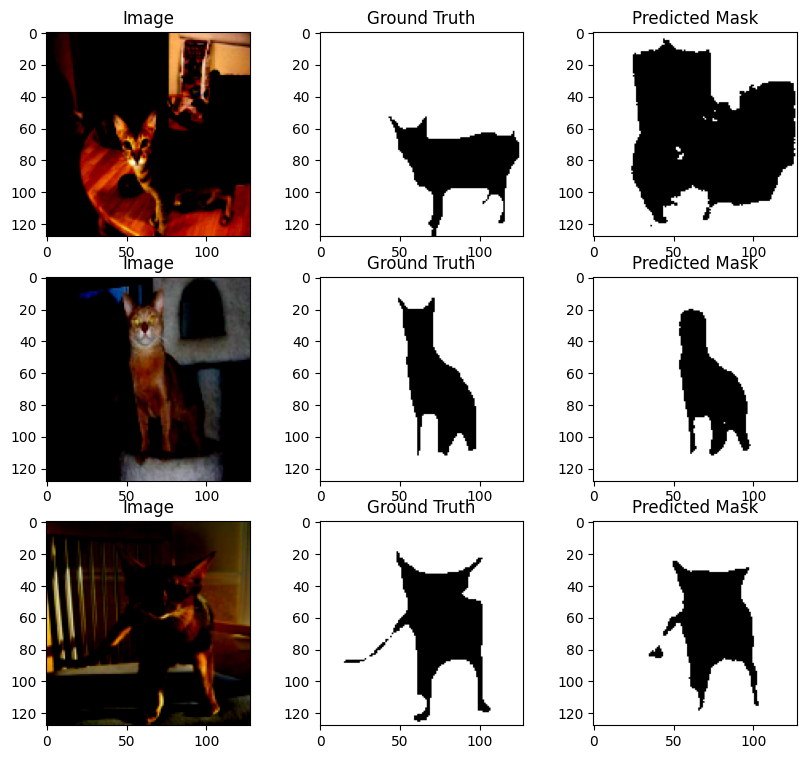

In [12]:
trainer.inference_and_plot_samples(n_samples=3)

Добавление нормализации к слоям лучшей модели привело к значительному росту функции потерь (с 0.1940 до 0.2833) при незначительном снижении метрик качества сегментации (IoU 0.8933 → 0.8878, F1 0.9399 → 0.9363). Это свидетельствует о том, что базовая модель уже достигла оптимального баланса, а нормализация нарушила устоявшееся распределение активаций, сделав предсказания менее уверенными.